In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-03-03 16:13:32.103321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772554412.301265      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772554412.351393      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772554412.785429      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772554412.785483      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772554412.785487      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras.datasets import cifar100
from sklearn.model_selection import train_test_split
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (45000, 32, 32, 3)
Val: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [5]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 64  # Reduce to 32 if GPU < 16GB

def preprocess(image, label):
    # Convert to float32 first
    image = tf.cast(image, tf.float32)

    # Resize on-the-fly (NOT all at once)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Apply ImageNet preprocessing
    image = preprocess_input(image)

    return image, label

# ---- TRAIN DATASET ----
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# ---- VALIDATION DATASET ----
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# ---- TEST DATASET ----
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

I0000 00:00:1772554441.232959      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.initializers import HeNormal

NUM_CLASSES = 100
WEIGHT_DECAY = 1e-4

# Load pretrained backbone
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze backbone (Feature Extraction Phase)
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
inputs = layers.Input(shape=(224, 224, 3))

# Backbone
x = base_model(inputs, training=False)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)

# Dense Layer (He Initialization + L2)
x = layers.Dense(
    512,
    kernel_initializer=HeNormal(),
    kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
    use_bias=False
)(x)

# Batch Normalization
x = layers.BatchNormalization()(x)

# ReLU Activation
x = layers.Activation('relu')(x)

# Dropout
x = layers.Dropout(0.5)(x)

# Final Output Layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax',
    kernel_regularizer=regularizers.l2(WEIGHT_DECAY)
)(x)

model = models.Model(inputs, outputs)

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,689,636 (94.18 MB)

 Trainable params: 1,100,900 (4.20 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [9]:
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

INITIAL_LR = 1e-3

optimizer = AdamW(
    learning_rate=INITIAL_LR,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_feature_extraction_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [11]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_scheduler, checkpoint]
)

Epoch 1/20


I0000 00:00:1772554453.390513     118 service.cc:152] XLA service 0x7e5b400030f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772554453.390559     118 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772554455.447703     118 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.0078 - loss: 5.3957       

I0000 00:00:1772554461.843297     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4529 - loss: 2.3912
Epoch 1: val_loss improved from inf to 1.20384, saving model to best_feature_extraction_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 103ms/step - accuracy: 0.4530 - loss: 2.3903 - val_accuracy: 0.6920 - val_loss: 1.2038 - learning_rate: 0.0010
Epoch 2/20
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6771 - loss: 1.2729
Epoch 2: val_loss improved from 1.20384 to 1.14545, saving model to best_feature_extraction_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.6771 - loss: 1.2729 - val_accuracy: 0.7178 - val_loss: 1.1455 - learning_rate: 0.0010
Epoch 3/20
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7228 - loss: 1.1394
Epoch 3: val_loss improved from 1.14545 to 1.14543, saving model to best_feature_extraction_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.7228 - loss: 1.1394 - val_accuracy: 0.7240 - val_loss: 1.1454 - learning_rate: 0.0010
Epoch 4/20
7

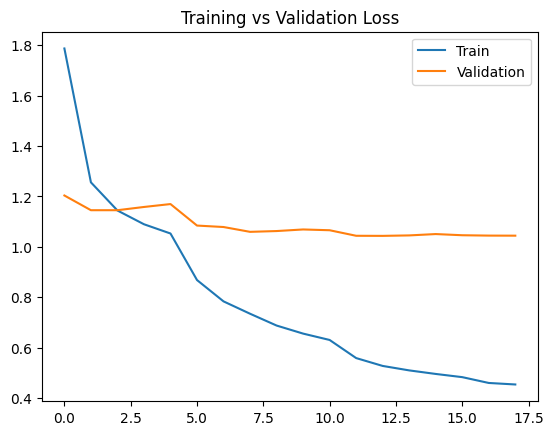

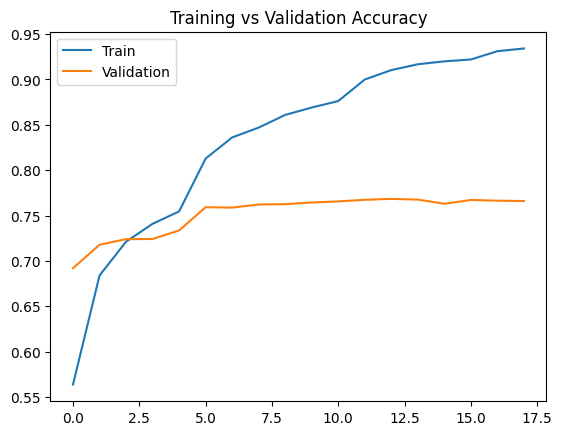

In [12]:
def plot_training(history):
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Training vs Validation Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("Training vs Validation Accuracy")
    plt.legend(["Train", "Validation"])
    plt.show()

plot_training(history)

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.7571 - loss: 1.0799
Test Accuracy: 0.7599999904632568


In [14]:
model.load_weights('best_feature_extraction_model.keras')

In [15]:
# Unfreeze last N layers
N = 30  # You can experiment with 20, 30, 50

for layer in base_model.layers[-N:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

In [16]:
FINE_TUNE_LR = 1e-5

optimizer = AdamW(
    learning_rate=FINE_TUNE_LR,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
FINE_TUNE_EPOCHS = 15

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 130ms/step - accuracy: 0.9107 - loss: 0.5218 - val_accuracy: 0.7748 - val_loss: 1.0315 - learning_rate: 1.0000e-05
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9329 - loss: 0.4629 - val_accuracy: 0.7732 - val_loss: 1.0212 - learning_rate: 1.0000e-05
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9469 - loss: 0.4233 - val_accuracy: 0.7738 - val_loss: 1.0287 - learning_rate: 1.0000e-05
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9561 - loss: 0.3913 - val_accuracy: 0.7768 - val_loss: 1.0246 - learning_rate: 1.0000e-05
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9656 - loss: 0.3655 - val_accuracy: 0.7754 - val_loss: 1.0164 - learning_rate: 1.0000e-05
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.9719 - loss: 0.3453 - val_accuracy: 0.7800 - val_loss: 1.0204 - learning_rate: 1.0000e-05
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 1

In [18]:
test_loss_ft, test_acc_ft = model.evaluate(test_ds)
print("Feature Extraction Test Accuracy:", test_acc)
print("Fine-Tuned Test Accuracy:", test_acc_ft)

157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.7787 - loss: 1.0571
Feature Extraction Test Accuracy: 0.7599999904632568
Fine-Tuned Test Accuracy: 0.7831000089645386


In [20]:
max(history.history['val_accuracy'])
max(history_fine.history['val_accuracy'])

0.7829999923706055

In [21]:
import numpy as np

# Get predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Flatten true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step


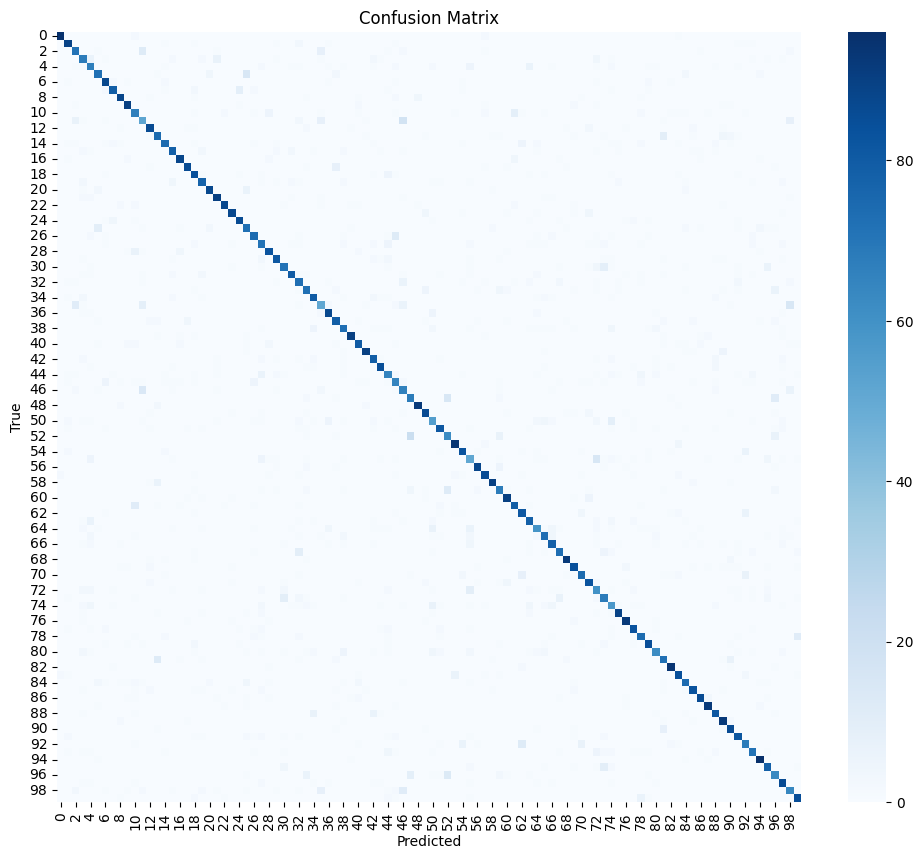

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [23]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       100
           1       0.83      0.89      0.86       100
           2       0.72      0.71      0.71       100
           3       0.64      0.68      0.66       100
           4       0.61      0.67      0.64       100
           5       0.76      0.72      0.74       100
           6       0.81      0.87      0.84       100
           7       0.87      0.79      0.83       100
           8       0.87      0.88      0.88       100
           9       0.89      0.90      0.90       100
          10       0.65      0.67      0.66       100
          11       0.54      0.52      0.53       100
          12       0.85      0.86      0.86       100
          13       0.73      0.74      0.73       100
          14       0.84      0.74      0.79       100
          15       0.81      0.78      0.80       100
          16       0.89      0.88      0.88       100
          17       0.91    

In [24]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.2%}")

Class 0: 95.00%
Class 1: 89.00%
Class 2: 71.00%
Class 3: 68.00%
Class 4: 67.00%
Class 5: 72.00%
Class 6: 87.00%
Class 7: 79.00%
Class 8: 88.00%
Class 9: 90.00%
Class 10: 67.00%
Class 11: 52.00%
Class 12: 86.00%
Class 13: 74.00%
Class 14: 74.00%
Class 15: 78.00%
Class 16: 88.00%
Class 17: 86.00%
Class 18: 84.00%
Class 19: 77.00%
Class 20: 87.00%
Class 21: 90.00%
Class 22: 87.00%
Class 23: 87.00%
Class 24: 86.00%
Class 25: 72.00%
Class 26: 74.00%
Class 27: 71.00%
Class 28: 83.00%
Class 29: 81.00%
Class 30: 71.00%
Class 31: 80.00%
Class 32: 73.00%
Class 33: 72.00%
Class 34: 80.00%
Class 35: 51.00%
Class 36: 87.00%
Class 37: 79.00%
Class 38: 73.00%
Class 39: 90.00%
Class 40: 80.00%
Class 41: 90.00%
Class 42: 79.00%
Class 43: 85.00%
Class 44: 65.00%
Class 45: 65.00%
Class 46: 66.00%
Class 47: 68.00%
Class 48: 92.00%
Class 49: 86.00%
Class 50: 55.00%
Class 51: 81.00%
Class 52: 62.00%
Class 53: 94.00%
Class 54: 83.00%
Class 55: 51.00%
Class 56: 88.00%
Class 57: 86.00%
Class 58: 90.00%
Class 5

In [25]:
num_hardest = 5  # Top 5 hardest classes
hardest_idx = np.argsort(per_class_acc)[:num_hardest]

print("Hardest classes:")
for idx in hardest_idx:
    print(f"Class {idx}: Accuracy {per_class_acc[idx]:.2%}")

Hardest classes:
Class 55: Accuracy 51.00%
Class 35: Accuracy 51.00%
Class 11: Accuracy 52.00%
Class 50: Accuracy 55.00%
Class 74: Accuracy 57.00%


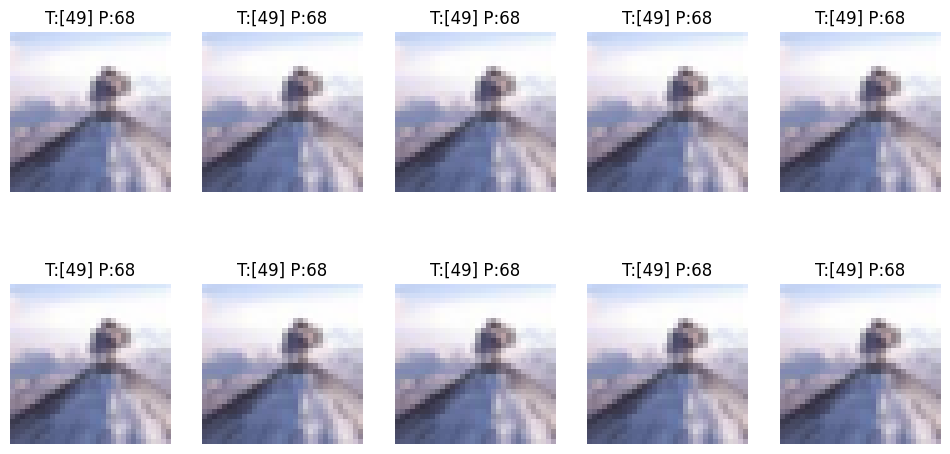

In [26]:
import matplotlib.pyplot as plt

mis_idx = np.where(y_true != y_pred)[0][:10]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(mis_idx):
    plt.subplot(2, 5, i+1)
    plt.imshow((X_test[idx].astype(np.uint8)))
    plt.title(f"T:{y_true[idx]} P:{y_pred[idx]}")
    plt.axis('off')
plt.show()